# Tidsstruktur

Pandas hjelper oss med å strukturere indeks der radetikettene består av datoer eller tidspunkter. Dette er organisert i en egen klasse som heter DateTimeIndex. Med datetimeindex kan vi gjøre seleksjon, gruppering og analyse av tidsseriedata mye enklere og raskere.

Under er et eksempel på de fem første linjene av en `dataframe` med DateTimeIndex.

Metoden .head() gir de første angitte antall reader, default er 5.

df.head(5)

```text
                           Production  Consumption
Time(Local)
2026-01-01 00:00:00+01:00    18448,59     16662,95
2026-01-01 01:00:00+01:00    18693,66     14953,24
2026-01-01 02:00:00+01:00    18639,68     14298,07
2026-01-01 03:00:00+01:00    18502,66     13254,81
2026-01-01 04:00:00+01:00    18458,45     12678,51
```

##### Bruksområde

DateTime Index er en klasse i pandas som brukes til å representere en indeks bestående av datoer og tidspunkter.

- spesialisert type Index i pandas,
- optimalisert for tidsseriedata (som kraftsystemdata)
- ekstra metoder som .year, .month, .day, tidsfiltrering, resampling osv.
- rydde og strukturere data
- gjøre beregninger og statistikk
- analysere tidsserier

## Internasjonal standard

For å blant annet kunne behandle geografiske tidsforskjeller benyttes Coordinated Universal Time (UTC), en felles referansetid som aldri forandrer seg

UTC brukes fordi:
 - ingen sommertid → ingen forvirring
 - gjør data sammenlignbare globalt
 - unngår feil i tidsserier
 - standard i API-er, databaser og analyse

In [66]:
# TEST CELL

#from IPython.display import Image, display
#display(Image('../images/solur_natal.jpg'))

### Behov for tidsstandard

Fram til midten av 1800-tallet hadde hver by sin tid definert av solen ved hjelp av et solur som i Areia Preta i Natal, Brasil som vist i {numref}`fig-solur`. Før standardiseringen hadde hver plass hadde sin middeltid ([mean-time](https://www.rmg.co.uk/stories/time/greenwich-mean-time-gmt)).

```{figure} ../images/solur_natal.jpg
---
width: 70%
align: center
name: fig-solur
---
Solur ved Areia Preta i Natal, Brasil. Foto: Patrick (2005), Wikimedia Commons, CC BY-SA 3.0.
```

### Geografisk informasjonssystem (GIS)

GeoPandas er et Python-bibliotek for geografiske data. Det bygger på Pandas, Shapely og GeoJSON/Geo-spatiale formater, og gjør det mulig å analysere og visualisere geografiske objekter som punkter, linjer og polygoner.

GIS står for Geografisk informasjonssystem (på engelsk Geographic Information System).

I koden under lastes en `geodataframe` ved hjelp av biblioteket `geopandas`, `matplotlib` brukes til å plotte kart og figurer.

```python
import geopandas as gpd
import matplotlib.pyplot as plt

url = (
    "https://naturalearth.s3.amazonaws.com/"
    "110m_cultural/ne_110m_admin_0_countries.zip"
)

world = gpd.read_file(url)
```

Kartet hentes fra en nettjenesten [NaturalEarth](https://www.naturalearthdata.com/) som tilbyr gratis karttjenester, i både vektor og raster(piksel)-format, se {numref}`fig-map`, driftet frivillige på GitHub-repoet [natural-earth-vector](https://github.com/nvkelso/natural-earth-vector). Kartdataene ligger i [public domain](https://creativecommons.org/publicdomain/), som betyr at hvem som helst kan kopiere, bruke, endre, dele og bruke kommersiellt.

```{figure} ../images/NEV-Logo-color.png
---
width: 70%
align: center
name: fig-map
---
Natural Earth Map
```

In [ ]:
# TEST CELL

#from IPython.display import Image, display
#display(Image('../images/NEV-Logo-color.png'))

### [Bruksvilkår](https://www.naturalearthdata.com/about/terms-of-use/)
```text
Terms of Use
Public Domain All versions of Natural Earth raster + vector map data found on this website are in the public domain. You may use the maps in any manner, including modifying the content and design, electronic dissemination, and offset printing. The primary authors, Tom Patterson and Nathaniel Vaughn Kelso, and all other contributors renounce all financial claim to the maps and invites you to use them for personal, educational, and commercial purposes.

No permission is needed to use Natural Earth. Crediting the authors is unnecessary.

However, if you wish to cite the map data, simply use one of the following.

Short text:
Made with Natural Earth.

Long text:
Made with Natural Earth. Free vector and raster map data @ naturalearthdata.com.
```

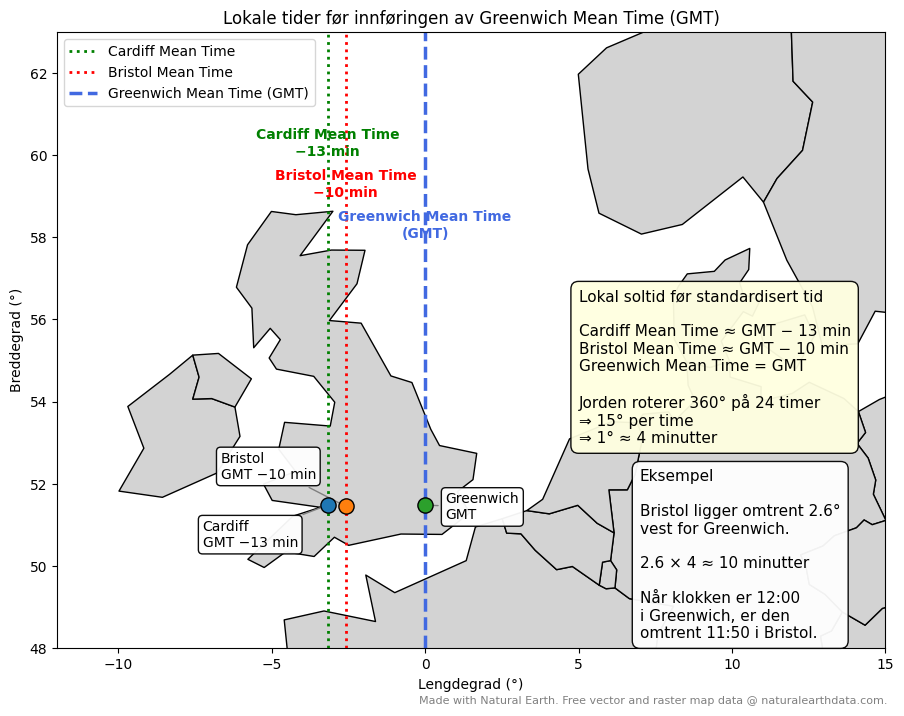

In [20]:
# TEST CELL
import geopandas as gpd
import matplotlib.pyplot as plt

# ==========================================================
# Kartgrunnlag
# ==========================================================

url = (
    "https://naturalearth.s3.amazonaws.com/"
    "110m_cultural/ne_110m_admin_0_countries.zip"
)

world = gpd.read_file(url)

# Europa
europe = world[world["CONTINENT"] == "Europe"]

# ==========================================================
# Byer og lokale tider
# ==========================================================

cities = {
    "Cardiff\nGMT −13 min": (-3.18, 51.48),
    "Bristol\nGMT −10 min": (-2.59, 51.45),
    "Greenwich\nGMT": (-0.014, 51.478),
}


fig, ax = plt.subplots(figsize=(16, 8))

# Kart
europe.plot(
    ax=ax,
    color="lightgrey",
    edgecolor="black",
)

# ==========================================================
# Mean Time-meridianer
# ==========================================================

# Cardiff Mean Time
ax.axvline(
    -3.18,
    color="green",
    linestyle=":",
    linewidth=2,
    label="Cardiff Mean Time",
)

# Bristol Mean Time
ax.axvline(
    -2.59,
    color="red",
    linestyle=":",
    linewidth=2,
    label="Bristol Mean Time",
)

# Greenwich Mean Time
ax.axvline(
    0,
    color="royalblue",
    linestyle="--",
    linewidth=2.5,
    label="Greenwich Mean Time (GMT)",
)

# ==========================================================
# Byer
# ==========================================================

for label, (x, y) in cities.items():

    if "Cardiff" in label:
        offset = (-90, -30)
    elif "Bristol" in label:
        offset = (-90, 20)
    else:
        offset = (15, -10)

    ax.scatter(
        x,
        y,
        s=120,
        zorder=5,
        edgecolor="black",
    )

    ax.annotate(
        label,
        (x, y),
        xytext=offset,
        textcoords="offset points",
        fontsize=10,
        bbox=dict(
            facecolor="white",
            alpha=0.95,
            boxstyle="round,pad=0.3",
        ),
        arrowprops=dict(
            arrowstyle="-",
            color="gray",
        ),
    )

# ==========================================================
# Etiketter øverst på meridianene
# ==========================================================

ax.text(
    -3.18,
    60,
    "Cardiff Mean Time\n−13 min",
    color="green",
    ha="center",
    fontsize=10,
    fontweight="bold",
)

ax.text(
    -2.59,
    59,
    "Bristol Mean Time\n−10 min",
    color="red",
    ha="center",
    fontsize=10,
    fontweight="bold",
)

ax.text(
    0,
    58,
    "Greenwich Mean Time\n(GMT)",
    color="royalblue",
    ha="center",
    fontsize=10,
    fontweight="bold",
)

# ==========================================================
# Forklaring
# ==========================================================

ax.text(
    5,
    53,
    (
        "Lokal soltid før standardisert tid\n\n"
        "Cardiff Mean Time ≈ GMT − 13 min\n"
        "Bristol Mean Time ≈ GMT − 10 min\n"
        "Greenwich Mean Time = GMT\n\n"
        "Jorden roterer 360° på 24 timer\n"
        "⇒ 15° per time\n"
        "⇒ 1° ≈ 4 minutter"
    ),
    fontsize=11,
    bbox=dict(
        facecolor="lightyellow",
        alpha=0.95,
        boxstyle="round,pad=0.5",
    ),
)

# ==========================================================
# Regneeksempel
# ==========================================================

ax.text(
    7,
    48.25,
    (
        "Eksempel\n\n"
        "Bristol ligger omtrent 2.6°\n"
        "vest for Greenwich.\n\n"
        "2.6 × 4 ≈ 10 minutter\n\n"
        "Når klokken er 12:00\n"
        "i Greenwich, er den\n"
        "omtrent 11:50 i Bristol."
    ),
    fontsize=11,
    bbox=dict(
        facecolor="white",
        alpha=0.95,
        boxstyle="round,pad=0.5",
    ),
)

# ==========================================================
# Område
# ==========================================================

ax.set_xlim(-12, 15)
ax.set_ylim(48, 63)

ax.set_xlabel("Lengdegrad (°)")
ax.set_ylabel("Breddegrad (°)")

ax.set_title(
    "Lokale tider før innføringen av Greenwich Mean Time (GMT)"
)

ax.legend(
    loc="upper left"
)

plt.figtext(0.48, 0.04, "Made with Natural Earth. Free vector and raster map data @ naturalearthdata.com.",
ha="left",
fontsize=8,
color="gray"
)

plt.show()

#### Matematisk utlegning

Jorden roterer én gang rundt sin egen akse på 24 timer, som tilsvarer en rotasjon på $360^\circ$. Sammenhengen mellom lengdegrad og tid kan derfor utledes som

$$
360^\circ \leftrightarrow 24 \text{ timer}.
$$

Det betyr at

$$
15^\circ \leftrightarrow 1 \text{ time},
$$

fordi

$$
\frac{360^\circ}{24}=15^\circ.
$$



Siden én time er 60 minutter, får vi

$$
15^\circ \leftrightarrow 60 \text{ minutter}.
$$

Dividerer vi begge sider med 15, får vi

$$
1^\circ \leftrightarrow 4 \text{ minutter}.
$$

Dermed gjelder den generelle sammenhengen

$$
\boxed{\Delta t = 4\,\Delta \lambda}
$$

der

- $\Delta t$ er tidsforskjellen i minutter,
- $\Delta \lambda$ er forskjellen i lengdegrad i grader.



Greenwich ligger på nullmeridianen $0^\circ$, mens Bristol ligger omtrent $2.6^\circ$ vest for Greenwich:

$$
\Delta \lambda = 2.6^\circ.
$$

Tidsforskjellen blir derfor

$$
\Delta t
=
4 \cdot 2.6
=
10.4 \text{ minutter}.
$$

Altså ligger lokal soltid i Bristol omtrent 10 minutter etter Greenwich Mean Time (GMT):

$$
\boxed{\text{Bristol Mean Time} \approx \text{GMT} - 10 \text{ minutter}}.
$$



Tilsvarende ligger Cardiff omtrent $3.2^\circ$ vest for Greenwich:

$$
\Delta t
=
4 \cdot 3.2
=
12.8 \text{ minutter}
\approx
13 \text{ minutter}.
$$

Dermed får vi

$$
\boxed{\text{Cardiff Mean Time} \approx \text{GMT} - 13 \text{ minutter}}.
$$

Dette forklarer hvorfor byer på ulike lengdegrader hadde forskjellige lokale soltider før innføringen av standardisert tid og Greenwich Mean Time (GMT).



#### Jernbanetid (Railway time)

Etterhvert som jernbanenettet ble større og reisene lengre ble det mange lokale tider å holde styr på. For å holde styr på tidsforskjellene fikk man det standardiserte Railway time.


```{figure} ../images/Setesdalsbanen_2022.jpg
---
width: 70%
name: fig-setesdalsbanen
---
Setesdalsbanen ved Grovane.

*Kilde:* Even Harbo, «Setesdalsbanen 2022.jpg», Wikimedia Commons, CC BY-SA 4.0.
```

In [68]:
# TEST CELL

#from IPython.display import Image, display
#display(Image('../images/Setesdalsbanen_2022.jpg'))

Som vist i {numref}`fig-bradshaw-1840`, ble rutetabeller allerede i 1840 publisert for lange jernbanestrekninger som knyttet sammen byer med ulike lokale soltider. Dette bidro til innføringen av standardisert jernbanetid basert på Greenwich Mean Time (GMT).

In [69]:
# TEST CELL

#from IPython.display import Image, display
#display(Image('../images/exchangeclock.jpg'))

```{figure} ../images/bradshaw_1840_timetable.png
---
width: 70%
align: center
name: fig-bradshaw-1840
---
**Great Western Railway-rutetable fra Bradshaw's Railway Companion (1840).**
Tabellen viser avganger mellom London, Reading og andre stasjoner langs Great Western Railway, samt forbindelser mellom Bristol og Bath. På denne tiden gikk britiske jernbaneselskaper gradvis over fra lokale soltider til standardisert «London Time» (Greenwich Mean Time, GMT) for å unngå forvirring i rutetabellene. Kilde: Bradshaw (1840).
```

In [70]:
# TEST CELL

#from IPython.display import Image, display
#display(Image('../images/bradshaw_1840_timetable.png'))

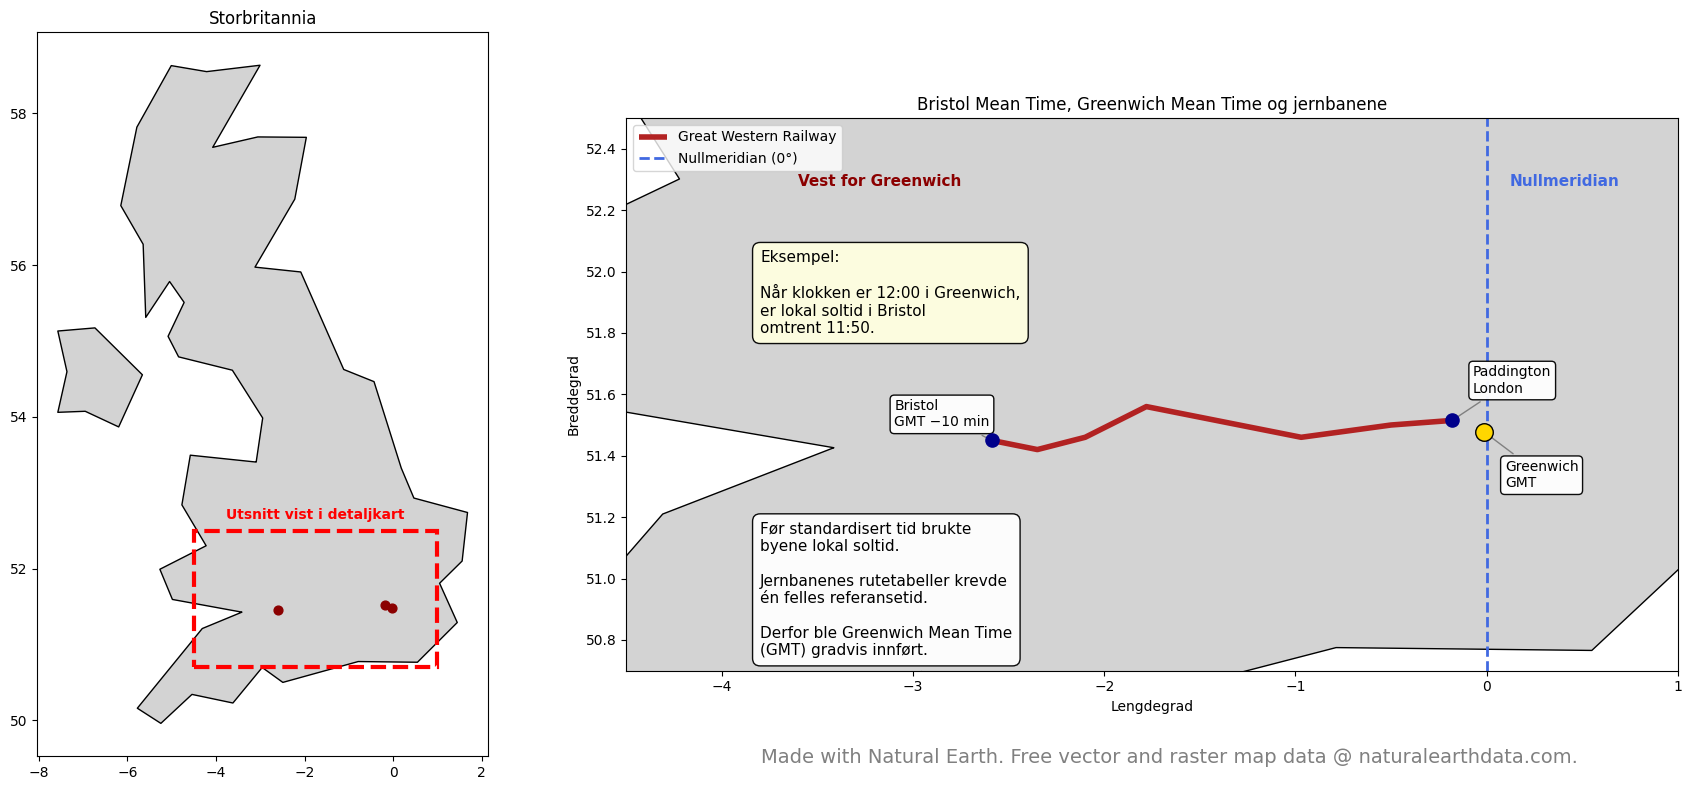

In [23]:
# TEST CELL
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString
from matplotlib.patches import Rectangle

# ==========================================================
# Storbritannia
# ==========================================================

url = (
    "https://naturalearth.s3.amazonaws.com/"
    "110m_cultural/ne_110m_admin_0_countries.zip"
)

world = gpd.read_file(url)
uk = world[world["ADMIN"] == "United Kingdom"]

# ==========================================================
# Viktige steder
# ==========================================================

cities = {
    "Bristol\nGMT −10 min": (-2.59, 51.45),
    "Paddington\nLondon": (-0.18, 51.515),
    "Greenwich\nGMT": (-0.014, 51.478),
}

label_offsets = {
    "Bristol\nGMT −10 min": (-70, 10),
    "Paddington\nLondon": (15, 20),
    "Greenwich\nGMT": (15, -40),
}

# ==========================================================
# Forenklet Great Western Railway
# ==========================================================

rail_coords = [
    (-2.59, 51.45),   # Bristol
    (-2.35, 51.42),   # Bath-området
    (-2.10, 51.46),   # Chippenham-området
    (-1.78, 51.56),   # Swindon
    (-0.97, 51.46),   # Reading
    (-0.50, 51.50),
    (-0.18, 51.515),  # Paddington
]

railway = gpd.GeoDataFrame(
    geometry=[LineString(rail_coords)],
    crs="EPSG:4326"
)

# ==========================================================
# Figur med to paneler
# ==========================================================

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(18, 8),
    gridspec_kw={"width_ratios": [1, 1.5]}
)

# ==========================================================
# VENSTRE PANEL: Storbritannia
# ==========================================================

uk.plot(
    ax=ax1,
    color="lightgrey",
    edgecolor="black"
)

# Området som zoomes inn i høyre figur
zoom_rect = Rectangle(
    (-4.5, 50.7),   # xmin, ymin
    5.5,            # bredde
    1.8,            # høyde
    fill=False,
    edgecolor="red",
    linestyle="--",
    linewidth=3
)

ax1.add_patch(zoom_rect)

# Vis de tre stedene også på oversiktskartet
for label, (x, y) in cities.items():

    ax1.scatter(
        x,
        y,
        color="darkred",
        s=40,
        zorder=10
    )

ax1.annotate(
    "Utsnitt vist i detaljkart",
    (-1.75, 52.65),
    color="red",
    fontsize=10,
    fontweight="bold",
    ha="center"
)

ax1.set_title(
    "Storbritannia"
)

# ==========================================================
# HØYRE PANEL: Bristol–London-korridoren
# ==========================================================

uk.plot(
    ax=ax2,
    color="lightgrey",
    edgecolor="black"
)

railway.plot(
    ax=ax2,
    color="firebrick",
    linewidth=4,
    label="Great Western Railway"
)

# Byer
for label, (x, y) in cities.items():

    ax2.scatter(
        x,
        y,
        color="darkblue",
        s=90,
        zorder=10,
    )

    dx, dy = label_offsets[label]

    ax2.annotate(
        label,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            alpha=0.95,
        ),
        arrowprops=dict(
            arrowstyle="-",
            color="gray",
            lw=1,
        ),
    )

# Nullmeridian
ax2.axvline(
    0,
    color="royalblue",
    linestyle="--",
    linewidth=2,
    label="Nullmeridian (0°)"
)

# Fremhev Greenwich
ax2.scatter(
    -0.014,
    51.478,
    color="gold",
    edgecolor="black",
    s=160,
    zorder=11,
)

# Tidsforskjell
ax2.text(
    -3.8,
    51.8,
    "Eksempel:\n\n"
    "Når klokken er 12:00 i Greenwich,\n"
    "er lokal soltid i Bristol\n"
    "omtrent 11:50.",
    fontsize=11,
    bbox=dict(
        facecolor="lightyellow",
        alpha=0.95,
        boxstyle="round,pad=0.5",
    ),
)

# Historisk forklaring
ax2.text(
    -3.8,
    50.75,
    "Før standardisert tid brukte\n"
    "byene lokal soltid.\n\n"
    "Jernbanenes rutetabeller krevde\n"
    "én felles referansetid.\n\n"
    "Derfor ble Greenwich Mean Time\n"
    "(GMT) gradvis innført.",
    fontsize=11,
    bbox=dict(
        facecolor="white",
        alpha=0.95,
        boxstyle="round,pad=0.5",
    ),
)

# Vis vest/øst
ax2.text(
    -3.6,
    52.28,
    "Vest for Greenwich",
    fontsize=11,
    color="darkred",
    fontweight="bold",
)

ax2.text(
    0.12,
    52.28,
    "Nullmeridian",
    fontsize=11,
    color="royalblue",
    fontweight="bold",
)

# Zoom inn på Sør-England
ax2.set_xlim(-4.5, 1.0)
ax2.set_ylim(50.7, 52.5)

ax2.set_xlabel("Lengdegrad")
ax2.set_ylabel("Breddegrad")

ax2.set_title(
    "Bristol Mean Time, Greenwich Mean Time og jernbanene"
)

ax2.legend(loc="upper left")

plt.figtext(0.48, 0.04, "Made with Natural Earth. Free vector and raster map data @ naturalearthdata.com.",
ha="left",
fontsize=14,
color="gray"
)

plt.tight_layout()
plt.show()

### Lage Datetime
I cellen under kaller vi på importerer vi datetime, timezone, fra datetme som er et begrep og en klasse i Python som brukes til å representere dato og tidspunkt

Den inneholder:

- år: 2026
- måned: 1
- dag: 1
- time: 13
- minutt: 45
- sekund: 00

In [1]:
from datetime import datetime

t = datetime(2026, 1, 1, 13, 45)
print(t)


2026-01-01 13:45:00


Vi oppdager fort at denne typen å representere tid på ikke vil fungere fordi den ikke tar høyde for tidssoner eller normaltid/sommertid.

Dette løses i timezone med å bruke utc:

In [2]:
from datetime import datetime, timezone

utc_now = datetime.now(timezone.utc)
print(utc_now)


2026-05-27 12:16:50.789300+00:00


| Sted              | Tid                      |
|-------------------|--------------------------|
| UTC               | 12:00                    |
| Norge (vinter)    | 13:00 (UTC +1)           |
| Norge (sommer)    | 14:00 (UTC +2)           |
| New York          | 07:00 (UTC −5)           |

In [38]:
import pandas as pd

df = pd.read_csv("../data/load_data.csv", sep=",")
print(df.head())

                  Time(Local) Production Consumption
0  01.01.2026 00:00:00 +01:00   18448,59    16662,95
1  01.01.2026 01:00:00 +01:00   18693,66    14953,24
2  01.01.2026 02:00:00 +01:00   18639,68    14298,07
3  01.01.2026 03:00:00 +01:00   18502,66    13254,81
4  01.01.2026 04:00:00 +01:00   18458,45    12678,51


In [39]:
print(df.columns)

Index(['Time(Local)', 'Production', 'Consumption'], dtype='object')


## Hva er en tidsserie?
I kraftsystemer jobber vi ofte med tidsserier:
data som er målt over tid
Eksempel:

last (MW)

produksjon

frekvens

### Viktig: DatetimeIndex

En vanlig index er bare “labels”.
Men DatetimeIndex gir deg tidsforståelse innebygd, som betyr at du kan hente ut tid direkte.

 - df.index.hour
 - df.index.day
 - df.index.month
 - df.index.year

Dette er veldig nyttig når vi jobber med tidsserier

For å analysere tidsserier setter vi tid som indeks:

Selv med parse_dates, kan pandas feile hvis formatet er rart.

In [36]:
df = pd.read_csv("../data/load_data.csv", parse_dates=["Time(Local)"])
df.head()

,Time(Local),Production,Consumption
0,01.01.2026 00:00:00 +01:00,"18448,59","16662,95"
1,01.01.2026 01:00:00 +01:00,"18693,66","14953,24"
2,01.01.2026 02:00:00 +01:00,"18639,68","14298,07"
3,01.01.2026 03:00:00 +01:00,"18502,66","13254,81"
4,01.01.2026 04:00:00 +01:00,"18458,45","12678,51"


#### .iloc
.iloc() metoden i pandas gjør det mulig å hente ut data basert på indeksnummer [rad,kolonne]

Kolontegn betyr alle; slik at [:,1] er alle rader i kolonne 2.

In [43]:
print(df.iloc[:,1])

Time(Local)
2026-01-01 00:00:00+01:00    16662,95
2026-01-01 01:00:00+01:00    14953,24
2026-01-01 02:00:00+01:00    14298,07
2026-01-01 03:00:00+01:00    13254,81
2026-01-01 04:00:00+01:00    12678,51
                               ...   
2026-05-20 19:00:00+02:00    19331,51
2026-05-20 20:00:00+02:00    20096,14
2026-05-20 21:00:00+02:00    19944,19
2026-05-20 22:00:00+02:00    19368,15
2026-05-20 23:00:00+02:00    18385,77
Name: Consumption, Length: 3359, dtype: object


[2,:] er alle kolonner i rad 3.

In [44]:
print(df.iloc[2,:])

Production     18639,68
Consumption    14298,07
Name: 2026-01-01 02:00:00+01:00, dtype: object


### .loc

Den virkelige kraften til datetimeindex kommer med .loc-metoden.

Vi kan hente ut hele datoer

```python
df.loc["2026-01-01"]
```
henter ut alle verdiene fra 1. januar 2026



In [46]:
print(df.loc["2026-01-01"])

,Production,Consumption
Time(Local),,
2026-01-01 00:00:00+01:00,"18448,59","16662,95"
2026-01-01 01:00:00+01:00,"18693,66","14953,24"
2026-01-01 02:00:00+01:00,"18639,68","14298,07"
2026-01-01 03:00:00+01:00,"18502,66","13254,81"
2026-01-01 04:00:00+01:00,"18458,45","12678,51"
2026-01-01 05:00:00+01:00,"18636,48","12706,47"
2026-01-01 06:00:00+01:00,"18964,77","12967,66"
2026-01-01 07:00:00+01:00,"19279,57","13289,36"
2026-01-01 08:00:00+01:00,"19537,61","13593,11"


eller perioder

```python
df.loc["2026-01":"2026-03"]
```


In [47]:
print(df.loc["2026-01":"2026-03"])

                          Production Consumption
Time(Local)                                     
2026-01-01 00:00:00+01:00   18448,59    16662,95
2026-01-01 01:00:00+01:00   18693,66    14953,24
2026-01-01 02:00:00+01:00   18639,68    14298,07
2026-01-01 03:00:00+01:00   18502,66    13254,81
2026-01-01 04:00:00+01:00   18458,45    12678,51
...                              ...         ...
2026-03-31 19:00:00+02:00   16791,66    23472,70
2026-03-31 20:00:00+02:00   16981,86    22945,78
2026-03-31 21:00:00+02:00   16816,44    21933,62
2026-03-31 22:00:00+02:00   16511,72    21234,99
2026-03-31 23:00:00+02:00   16147,08    20762,10

[2159 rows x 2 columns]


In [37]:
print(df["Time(Local)"].head())
print(type(df["Time(Local)"].iloc[0]))

0    01.01.2026 00:00:00 +01:00
1    01.01.2026 01:00:00 +01:00
2    01.01.2026 02:00:00 +01:00
3    01.01.2026 03:00:00 +01:00
4    01.01.2026 04:00:00 +01:00
Name: Time(Local), dtype: object
<class 'str'>


In [7]:
print(df.columns)

Index(['Time(Local)', 'Production', 'Consumption'], dtype='object')


In [40]:

df.columns = df.columns.str.strip()

df["Time(Local)"] = pd.to_datetime(
    df["Time(Local)"],
    dayfirst=True,
    utc=True  
)

df = df.set_index("Time(Local)")
df = df.sort_index()

df = df.tz_convert("Europe/Oslo")


In [41]:
print(df.columns)

Index(['Production', 'Consumption'], dtype='object')


In [42]:
print(df.head())

                          Production Consumption
Time(Local)                                     
2026-01-01 00:00:00+01:00   18448,59    16662,95
2026-01-01 01:00:00+01:00   18693,66    14953,24
2026-01-01 02:00:00+01:00   18639,68    14298,07
2026-01-01 03:00:00+01:00   18502,66    13254,81
2026-01-01 04:00:00+01:00   18458,45    12678,51


Første linje i dataene 18448,59 er norsk format: , = desimaltegn

pandas har lest det som tekst

## FIX (konverter til tall)

In [11]:
df["Consumption"] = df["Consumption"].str.replace(",", ".").astype(float)

In [12]:
print(df.dtypes)

Production      object
Consumption    float64
dtype: object


Da kan vi gjøre:

In [13]:
analyse = df['Consumption'].resample("1D").mean()
print(analyse.head())

Time(Local)
2026-01-01 00:00:00+01:00    15464.587083
2026-01-02 00:00:00+01:00    19360.323333
2026-01-03 00:00:00+01:00    23015.297083
2026-01-04 00:00:00+01:00    23660.607500
2026-01-05 00:00:00+01:00    25149.064167
Freq: D, Name: Consumption, dtype: float64


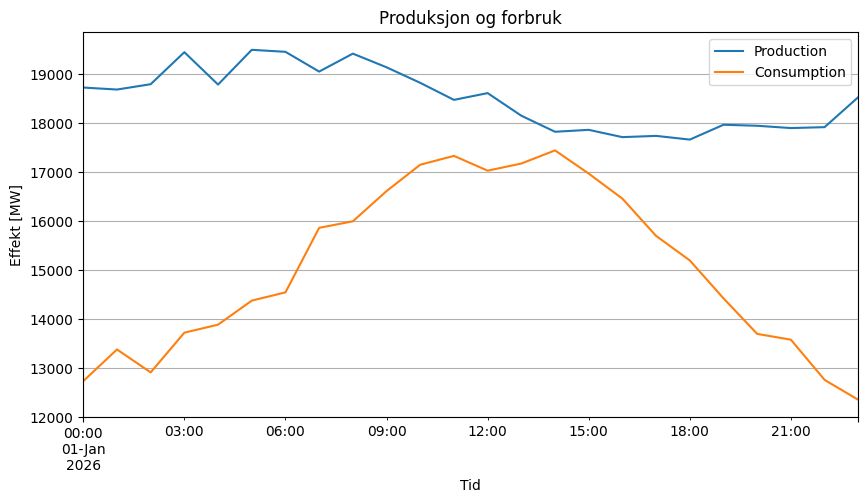

In [82]:
import matplotlib.pyplot as plt

df.plot(
    y=["Production", "Consumption"],
    figsize=(10, 5)
)

plt.title("Produksjon og forbruk")
plt.xlabel("Tid")
plt.ylabel("Effekt [MW]")
plt.grid(True)
plt.legend()

plt.show()

In [84]:
import pandas as pd
import numpy as np
time = pd.date_range(
    start="2026-01-01",
    periods=24,
    freq="h",
    tz="Europe/Oslo"
)

np.random.seed(42)

df1 = pd.DataFrame(

{

"Production": np.random.randint(17000, 20000, size=len(time)),

"Consumption": np.random.randint(14000, 18000, size=len(time)),

},

index=time

)

df1.index.name = "Time(Local)"

In [85]:
print(time)

DatetimeIndex(['2026-01-01 00:00:00+01:00', '2026-01-01 01:00:00+01:00',
               '2026-01-01 02:00:00+01:00', '2026-01-01 03:00:00+01:00',
               '2026-01-01 04:00:00+01:00', '2026-01-01 05:00:00+01:00',
               '2026-01-01 06:00:00+01:00', '2026-01-01 07:00:00+01:00',
               '2026-01-01 08:00:00+01:00', '2026-01-01 09:00:00+01:00',
               '2026-01-01 10:00:00+01:00', '2026-01-01 11:00:00+01:00',
               '2026-01-01 12:00:00+01:00', '2026-01-01 13:00:00+01:00',
               '2026-01-01 14:00:00+01:00', '2026-01-01 15:00:00+01:00',
               '2026-01-01 16:00:00+01:00', '2026-01-01 17:00:00+01:00',
               '2026-01-01 18:00:00+01:00', '2026-01-01 19:00:00+01:00',
               '2026-01-01 20:00:00+01:00', '2026-01-01 21:00:00+01:00',
               '2026-01-01 22:00:00+01:00', '2026-01-01 23:00:00+01:00'],
              dtype='datetime64[ns, Europe/Oslo]', name='Time(Local)', freq='h')


In [86]:
print(df1)

                           Production  Consumption
Time(Local)                                       
2026-01-01 00:00:00+01:00       17860        17385
2026-01-01 01:00:00+01:00       18294        14021
2026-01-01 02:00:00+01:00       18130        16300
2026-01-01 03:00:00+01:00       18095        14747
2026-01-01 04:00:00+01:00       18638        16904
2026-01-01 05:00:00+01:00       19169        17632
2026-01-01 06:00:00+01:00       17466        14474
2026-01-01 07:00:00+01:00       18238        15082
2026-01-01 08:00:00+01:00       17330        16558
2026-01-01 09:00:00+01:00       18482        17753
2026-01-01 10:00:00+01:00       19135        16047
2026-01-01 11:00:00+01:00       19919        17547
2026-01-01 12:00:00+01:00       17130        16747
2026-01-01 13:00:00+01:00       18685        14975
2026-01-01 14:00:00+01:00       17769        15806
2026-01-01 15:00:00+01:00       19391        14189
2026-01-01 16:00:00+01:00       18515        17005
2026-01-01 17:00:00+01:00      

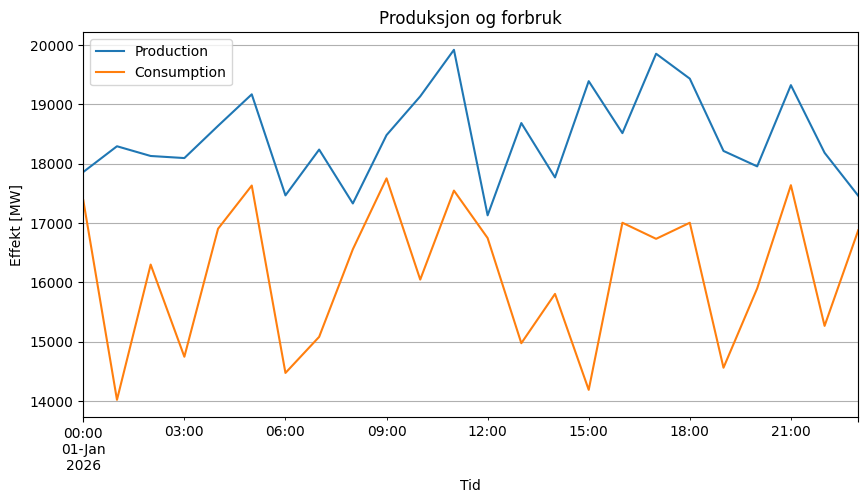

In [87]:
df1.plot(
    y=["Production", "Consumption"],
    figsize=(10, 5)
)

plt.title("Produksjon og forbruk")
plt.xlabel("Tid")
plt.ylabel("Effekt [MW]")
plt.grid(True)
plt.legend()

plt.show()

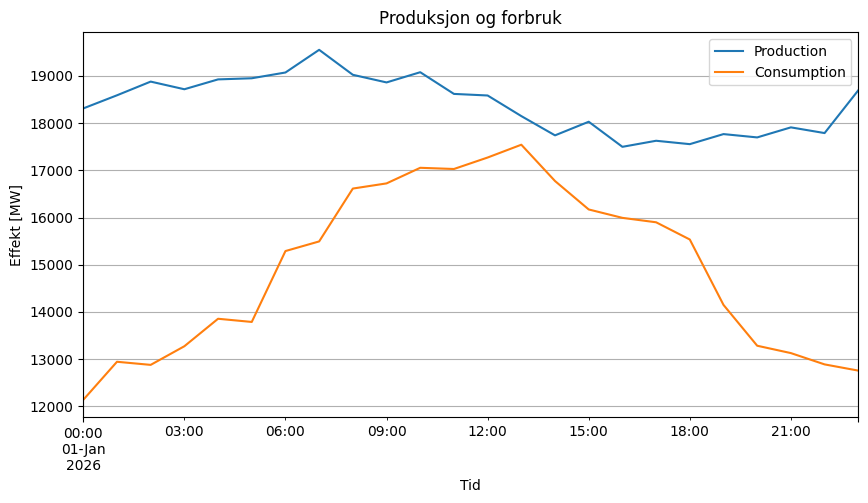

In [93]:
import numpy as np
import pandas as pd

hours = np.arange(24)

aproduction = (
    18500
    + 800 * np.sin(2 * np.pi * hours / 24)
    + np.random.normal(0, 200, 24)
)

aconsumption = (
    15000
    + 2500 * np.sin(2 * np.pi * (hours - 6) / 24)
    + np.random.normal(0, 300, 24)
)

df2 = pd.DataFrame(
    {
        "Production": aproduction.round(2),
        "Consumption": aconsumption.round(2),
    },
    index=time
)

df2.index.name = "Time(Local)"

df2.plot(
    y=["Production", "Consumption"],
    figsize=(10, 5)
)

plt.title("Produksjon og forbruk")
plt.xlabel("Tid")
plt.ylabel("Effekt [MW]")
plt.grid(True)
plt.legend()

plt.show()

## Motivasjon
Hvorfor dette er viktig i dette kurset
I dette kurset bruker vi pandas til å:
- lese ekte kraftsystemdata
- analysere lastprofiler
- finne mønstre i forbruk
- koble data til dynamiske modeller

## Kobling videre
Når dataene er klare, kan vi:

Lage en representativ døgnprofil
glatte data (Gaussian-filter)
analysere dynamikk (swing equation)